## CMPINF 2100 Week 11
### Working with LINEAR MODELS with ADDITIVE features

We will generate our own data for this example. This will again review the assumption of the LINEAR MODEL!!!

We will fit the model using `statsmodels`. We will interpret the results via the COEFFICIENT summaries. We will interpret results through PREDICTIONS. And we will use specialized `statsmodels` graphics to get further insights into the behavior

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
import statsmodels.formula.api as smf

## Linear Additive Features

We will work with 2 inputs but the ideas scale to MANY inputs

To create our own data we MUST specify the regression coefficients

In [3]:
b0 = -0.25
b1 = 1.95
b2 = 0.2

## Make random input data

Randomly generate input values for this problem. Let's assume both inputs have STANDARD NORMAL Distributions.

STANDARD NORMAL are Gaussians with MEAN 0 and STANDARD DEVIATION of 1

In [4]:
N = 35 ### number of observations

In [5]:
rg = np.random.default_rng(2100)

Call the random number generator for 2 inputs

In [6]:
input_df = pd.DataFrame({'x1': rg.normal(loc=0, scale=1, size = N),
                        'x2': rg.normal(loc=0, scale=1, size= N)})

In [8]:
input_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      35 non-null     float64
 1   x2      35 non-null     float64
dtypes: float64(2)
memory usage: 688.0 bytes


In [9]:
input_df

,x1,x2
0,1.024252,-0.650623
1,-1.733671,0.993904
2,-0.089294,0.251805
3,-1.093748,1.356543
4,0.320995,-0.145121
5,-1.103206,1.054346
6,-0.775994,-1.629940
7,-0.329677,-0.391626
8,-1.450625,2.538560
9,1.069088,-0.201595


Calculate the TREND or AVERAGE OUTPUT assuming the LINEAR ADDITIVE FEATURES

In [10]:
df = input_df.copy()

In [28]:
df['trend'] = b0 + b1 * df.x1 + b2 * df.x2

In [29]:
df.head()

,x1,x2,trend,y
0,1.024252,-0.650623,1.617167,2.590043
1,-1.733671,0.993904,-3.431878,0.132368
2,-0.089294,0.251805,-0.373762,1.676710
3,-1.093748,1.356543,-2.111500,0.849173
4,0.320995,-0.145121,0.346917,1.937263


The OUTPUT is NORMALLY distributed around the TREND!!!

We will call ONE MORE Gaussian random number generator!!!

We need to set the RESIDUAL ERROR or REMAINING VARIATION AROUND THE TREND!!!

In [30]:
my_sigma = 0.05

In [31]:
df['y'] = rg.normal(loc=df.trend, scale=my_sigma, size=df.shape[0])

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      35 non-null     float64
 1   x2      35 non-null     float64
 2   trend   35 non-null     float64
 3   y       35 non-null     float64
dtypes: float64(4)
memory usage: 1.2 KB


In [33]:
df.head()

,x1,x2,trend,y
0,1.024252,-0.650623,1.617167,1.567586
1,-1.733671,0.993904,-3.431878,-3.510933
2,-0.089294,0.251805,-0.373762,-0.352691
3,-1.093748,1.356543,-2.111500,-2.218024
4,0.320995,-0.145121,0.346917,0.328151


## Visualize the relationship between inputs and output

Start with the relationship between `x1` and `y`

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


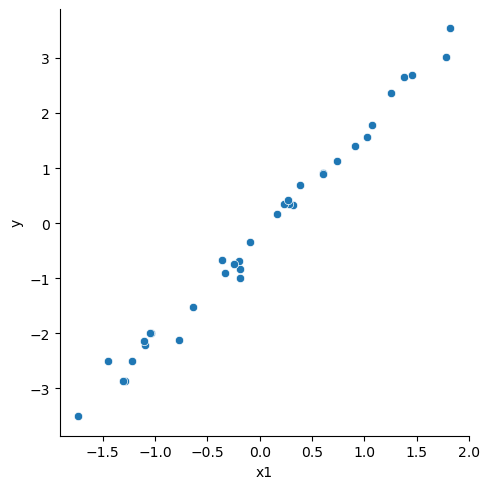

In [36]:
sns.relplot( data = df, x='x1', y='y', kind='scatter')
plt.show()

Let's now examine the relationship between `x2` and `y`

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


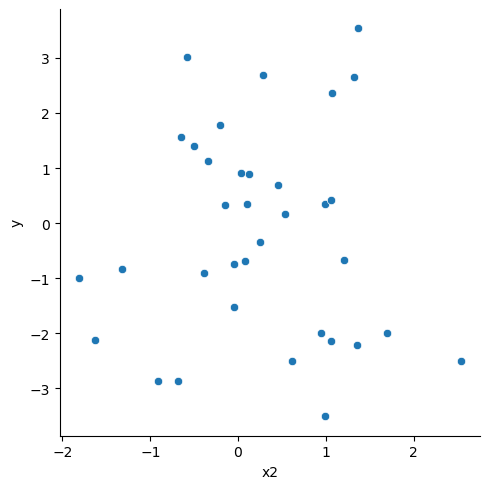

In [37]:
sns.relplot( data = df, x='x2', y='y', kind='scatter')
plt.show()

 Let's now examine the relationship between `x2` and `y`

We can include LINEAR TREND LINES to HELP identify POSSIBLE trends between the OUTPUT and the INPUTS!!!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


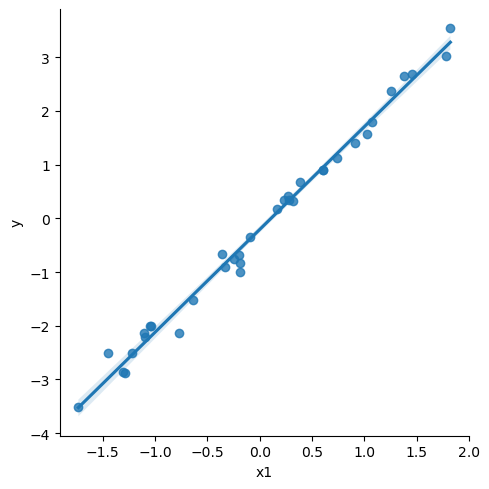

In [38]:
sns.lmplot(data = df, x='x1', y='y')
plt.show()

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


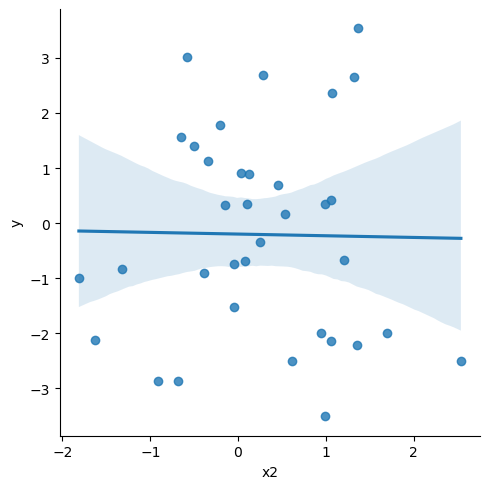

In [39]:
sns.lmplot(data = df, x='x2', y='y')
plt.show()

In [40]:
print(b2)

0.2


## Fit linear models to confirm the visualization

Fit a linear model with a LINEAR RELATIONSHIP between the TREND and `x1` By ITSELF

In [42]:
fit_x1 = smf.ols(formula='y ~ x1', data=df).fit()

In [44]:
fit_x1.params

Intercept   -0.207316
x1           1.913137
dtype: float64

In [45]:
fit_x1.bse

Intercept    0.032813
x1           0.033885
dtype: float64

In [46]:
fit_x1.pvalues

Intercept    3.793783e-07
x1           2.068308e-34
dtype: float64

In [47]:
fit_x1.pvalues < 0.05

Intercept    True
x1           True
dtype: bool

In [48]:
fit_x1.conf_int()

,0,1
Intercept,-0.274074,-0.140558
x1,1.844198,1.982075


In [51]:
fit_x1.conf_int().\
rename(columns={0: 'conf_lwr', 1: 'conf_upr'})

,conf_lwr,conf_upr
Intercept,-0.274074,-0.140558
x1,1.844198,1.982075


Fit a linear model between the TREND and `x2` BY ITSELF

In [52]:
fit_x2 = smf.ols(formula='y ~ x2', data=df).fit()

In [53]:
fit_x2.params

Intercept   -0.199589
x2          -0.030639
dtype: float64

In [54]:
fit_x2.bse

Intercept    0.335272
x2           0.341170
dtype: float64

In [56]:
fit_x2.pvalues < 0.05

Intercept    False
x2           False
dtype: bool

In [57]:
fit_x2.conf_int().\
rename(columns={0: 'conf_lwr', 1: 'conf_upr'})

,conf_lwr,conf_upr
Intercept,-0.881706,0.482527
x2,-0.724755,0.663478


### Visualize the COEFFICIENT SUMMARIES

In [58]:
def my_coefplot(mod, figsize_use=(10, 4)):
    fig, ax = plt.subplots(figsize=figsize_use)
    ax.errorbar(y=mod.params.index,
               x=mod.params,
               xerr = 2 * mod.bse,
               fmt= 'o', color='k', ecolor='k', elinewidth=2, ms=10)
    ax.axvline(x=0, linestyle='--', linewidth=3.5, color='grey')
    ax.set_xlabel('coefficient value')
    plt.show()

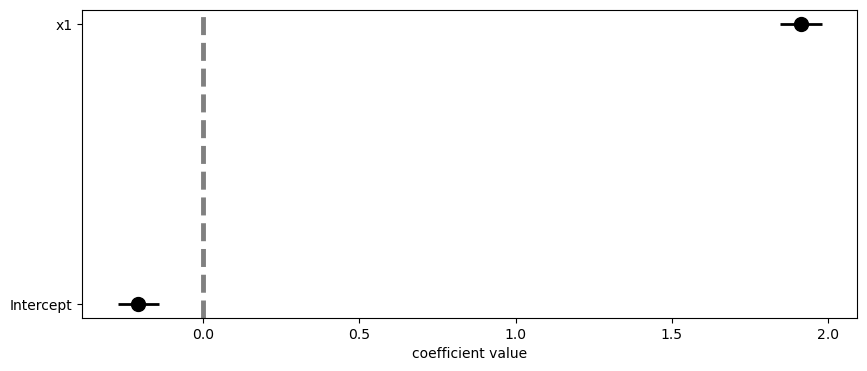

In [59]:
my_coefplot( fit_x1)

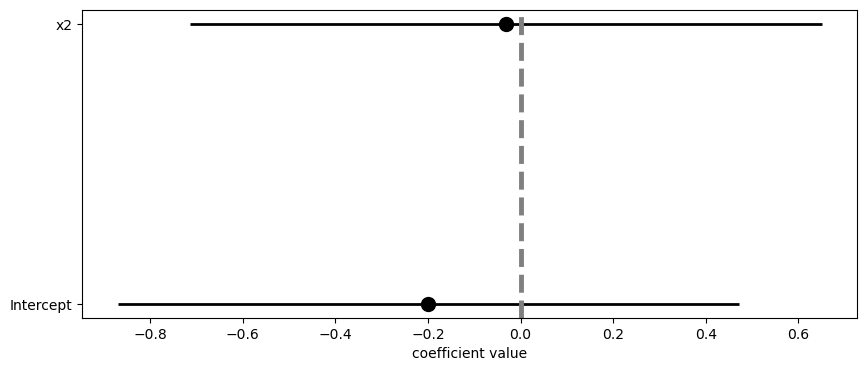

In [60]:
my_coefplot( fit_x2)

### Linear additive features with BOTH inputs

In [61]:
fit_x1x2_add = smf.ols(formula='y ~ x1 + x2', data=df).fit()

In [62]:
fit_x1x2_add.params

Intercept   -0.255679
x1           1.934499
x2           0.192452
dtype: float64

In [63]:
fit_x1x2_add.bse

Intercept    0.009199
x1           0.009239
x2           0.009417
dtype: float64

In [64]:
fit_x1x2_add.pvalues

Intercept    5.601825e-24
x1           8.987028e-52
x2           6.280442e-20
dtype: float64

In [65]:
fit_x1x2_add.pvalues < 0.05

Intercept    True
x1           True
x2           True
dtype: bool

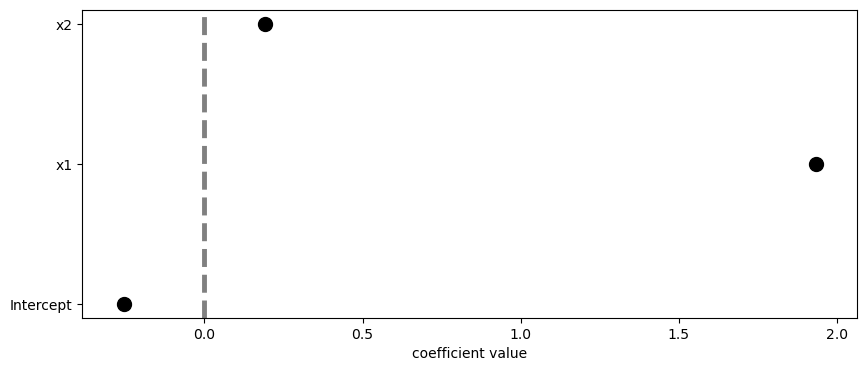

In [66]:
my_coefplot( fit_x1x2_add )

### Predictions

Predictions involving multiple inputs require DataFrame that have all inputs used to fit the model!!!
I like to VISUALIZE the RELATIONSHIPS between the OUTPUT and the MOST IMPORTANT INPUTS!!!

In [69]:
np.abs(fit_x1x2_add.params.sort_values(ascending=False))

x1           1.934499
x2           0.192452
Intercept    0.255679
dtype: float64

Create a DataFrame with MANY values of `x1` for a SINGLE value of `x2`

In [72]:
df_viz_1 = pd.DataFrame({'x1': np.linspace(df.x1.min()-0.02, df.x1.max()+0.02, num=251)})

In [74]:
df_viz_1['x2'] = df.x2.mean()

In [75]:
df_viz_1

,x1,x2
0,-1.753671,0.251296
1,-1.739287,0.251296
2,-1.724903,0.251296
3,-1.710519,0.251296
4,-1.696135,0.251296
...,...,...
246,1.784818,0.251296
247,1.799202,0.251296
248,1.813586,0.251296
249,1.827970,0.251296


When we make predictions we WANT to include TREND (average output), the uncertainty on the TREND ( the CONFIDENCE INTERVAL ) and the UNCERTAINTY of a SINGLE MEASUREMENT (the PREDICTION INTERVAL)

In [77]:
predictions_1 = fit_x1x2_add.get_prediction(df_viz_1)

In [78]:
pred_x1x2_add_summary = predictions_1.summary_frame()

In [79]:
pred_x1x2_add_summary

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,-3.599790,0.018481,-3.637435,-3.562146,-3.713337,-3.486244
1,-3.571964,0.018365,-3.609372,-3.534557,-3.685433,-3.458496
2,-3.544138,0.018249,-3.581309,-3.506967,-3.657529,-3.430748
3,-3.516312,0.018133,-3.553247,-3.479377,-3.629626,-3.402999
4,-3.488486,0.018017,-3.525185,-3.451787,-3.601723,-3.375250
...,...,...,...,...,...,...
246,3.245411,0.018734,3.207252,3.283570,3.131693,3.359129
247,3.273237,0.018851,3.234839,3.311635,3.159439,3.387036
248,3.301063,0.018968,3.262427,3.339700,3.187184,3.414943
249,3.328889,0.019086,3.290013,3.367765,3.214928,3.442850


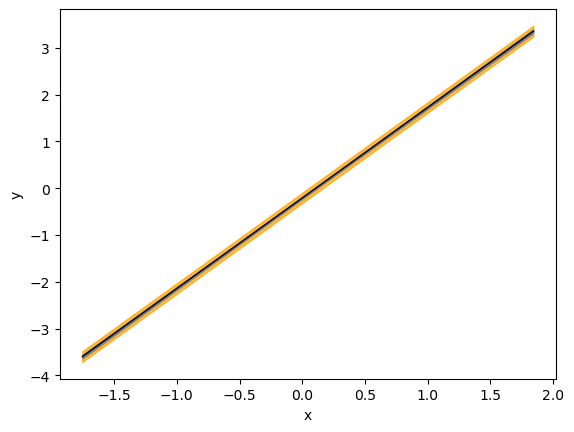

In [85]:
fig, ax = plt.subplots()

# prediction interval
ax.fill_between( df_viz_1.x1,
                pred_x1x2_add_summary.obs_ci_lower, pred_x1x2_add_summary.obs_ci_upper,
                facecolor='orange', alpha=0.75, edgecolor='orange')

# confidence interval
ax.fill_between( df_viz_1.x1,
                pred_x1x2_add_summary.mean_ci_lower, pred_x1x2_add_summary.mean_ci_upper,
                facecolor='grey', edgecolor='grey')

# trend
ax.plot( df_viz_1.x1, pred_x1x2_add_summary['mean'], color='k', linewidth=1)

# set the label
ax.set_xlabel('x')
ax.set_ylabel('y')

# show the plot
plt.show()

Now if we want to EXAMINE the INFLUENCE of the OTHER INPUTS...then we need to allow the `x2` INPUT to ALSO CHANGE!!!

The VISUALIZATION dataFrame must therefore consider MULTIPLE **COMBINATIONS** of the continuous inputs!!!

We need to create a GRID of INPUT COMBINATIONS Let's use LIST COMPREHENSIONS to manage for us!!!

In [87]:
input_grid = pd.DataFrame([ (x1, x2) for x1 in np.linspace( df.x1.min(), df.x1.max(), num=101)
                                      for x2 in np.linspace(df.x2.min(), df.x2.max(), num=9)],
                         columns=['x1', 'x2'])

In [88]:
input_grid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909 entries, 0 to 908
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      909 non-null    float64
 1   x2      909 non-null    float64
dtypes: float64(2)
memory usage: 14.3 KB


In [89]:
input_grid.nunique()

x1    101
x2      9
dtype: int64

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


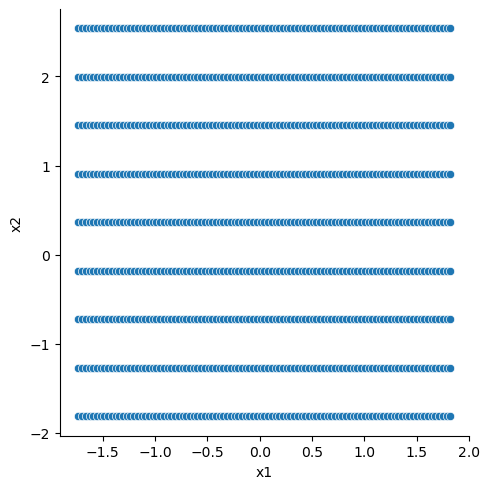

In [90]:
sns.relplot(data = input_grid, x='x1', y='x2', kind='scatter')
plt.show()

Let's PREDICT using the `input_grid` BUT...ONLY RETURNS the PREDICTED TRED!!! We will NOT return the UNCERTAINTY!!!

use the `.predict()` method to RETURN the PREDICTED TREND!!!

In [91]:
viz_grid = input_grid.copy()

In [92]:
viz_grid['pred'] = fit_x1x2_add.predict( input_grid )

In [93]:
viz_grid

,x1,x2,pred
0,-1.733671,-1.813330,-3.958442
1,-1.733671,-1.269344,-3.853751
2,-1.733671,-0.725357,-3.749059
3,-1.733671,-0.181371,-3.644368
4,-1.733671,0.362615,-3.539677
...,...,...,...
904,1.822354,0.362615,3.339449
905,1.822354,0.906601,3.444140
906,1.822354,1.450587,3.548831
907,1.822354,1.994573,3.653523


Let's COLOR the PREDICTED TREDN by each unique value of `x2` to show the RELATIONSHIP of the TREND with respect to `x1` for each unique value of `x2`!!!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


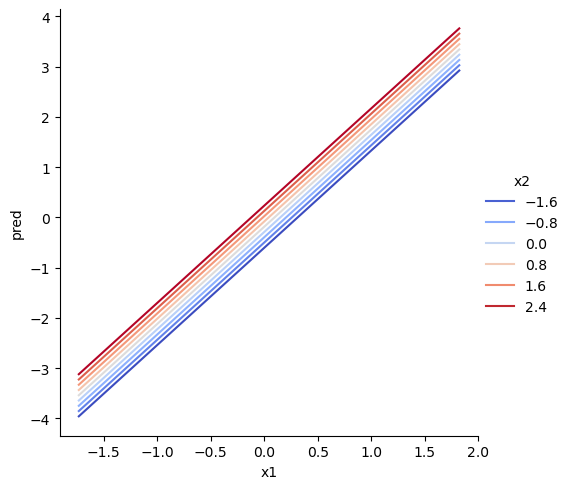

In [95]:
sns.relplot( data = viz_grid,
            x='x1', y='pred', kind='line',
            hue='x2', palette='coolwarm',
           estimator=None, units='x2' )
plt.show()

In [96]:
fit_x1x2_add.params

Intercept   -0.255679
x1           1.934499
x2           0.192452
dtype: float64

## Statsmodels specialized graphics
`statsmodels' has specialized graphics to help you with visualizations of your linear models.

BUT there are FEW THINGS you MUST remember when you use these funcitons


In [97]:
import statsmodels.api as sm

Creating these specialized figures requires initializing the FIGURE and AXIS objects via matplotlib.

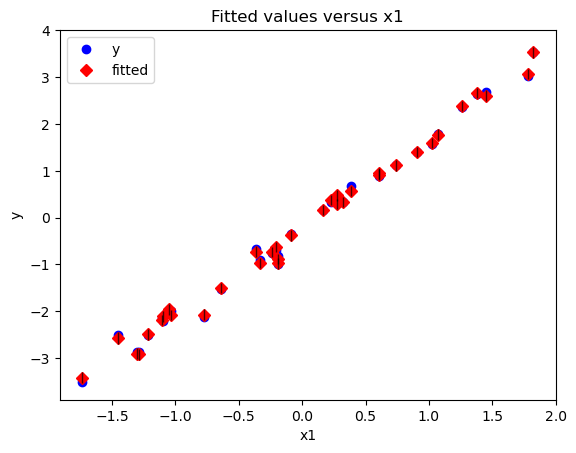

In [98]:
fig, ax = plt.subplots()

sm.graphics.plot_fit(fit_x1x2_add, 'x1', ax=ax)
plt.show()

Let's visualize the TRAINING SET FIT with respect to `x2`

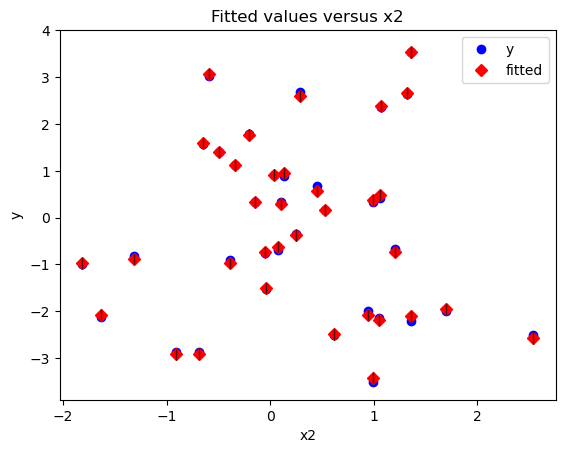

In [100]:
fig, ax = plt.subplots()

sm.graphics.plot_fit(fit_x1x2_add, 'x2', ax=ax)
plt.show()

We can examine the TRAINING set PREDICTIONS or FITS AND the RESIDUALS and the **PARTIAL regression point** in one figure

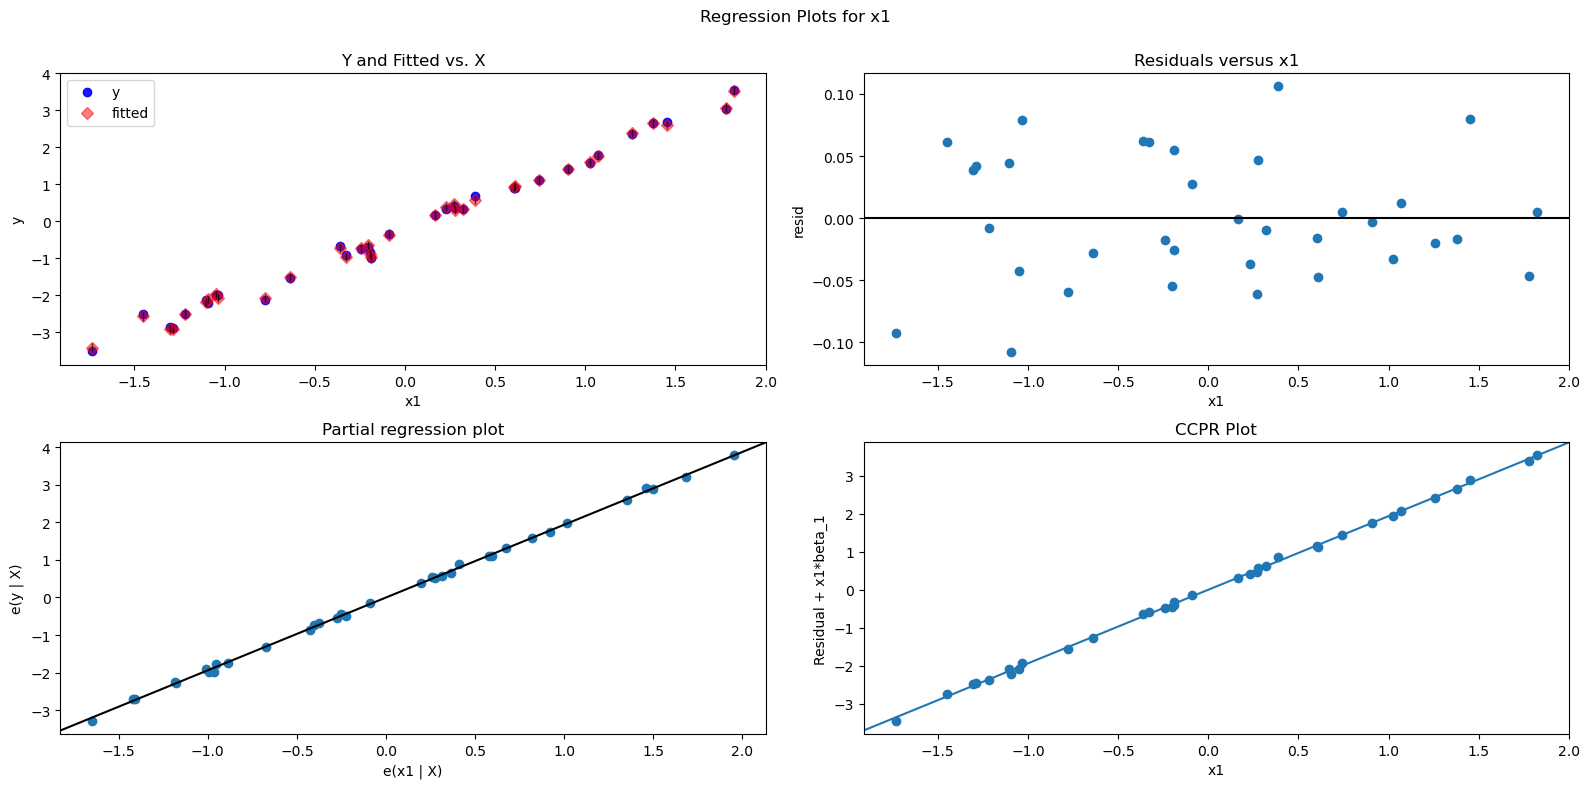

In [103]:
fig = plt.figure(figsize=(16, 8))
sm.graphics.plot_regress_exog(fit_x1x2_add, 'x1', fig=fig)
plt.show()

Look at teh partial regression plot for `x2`

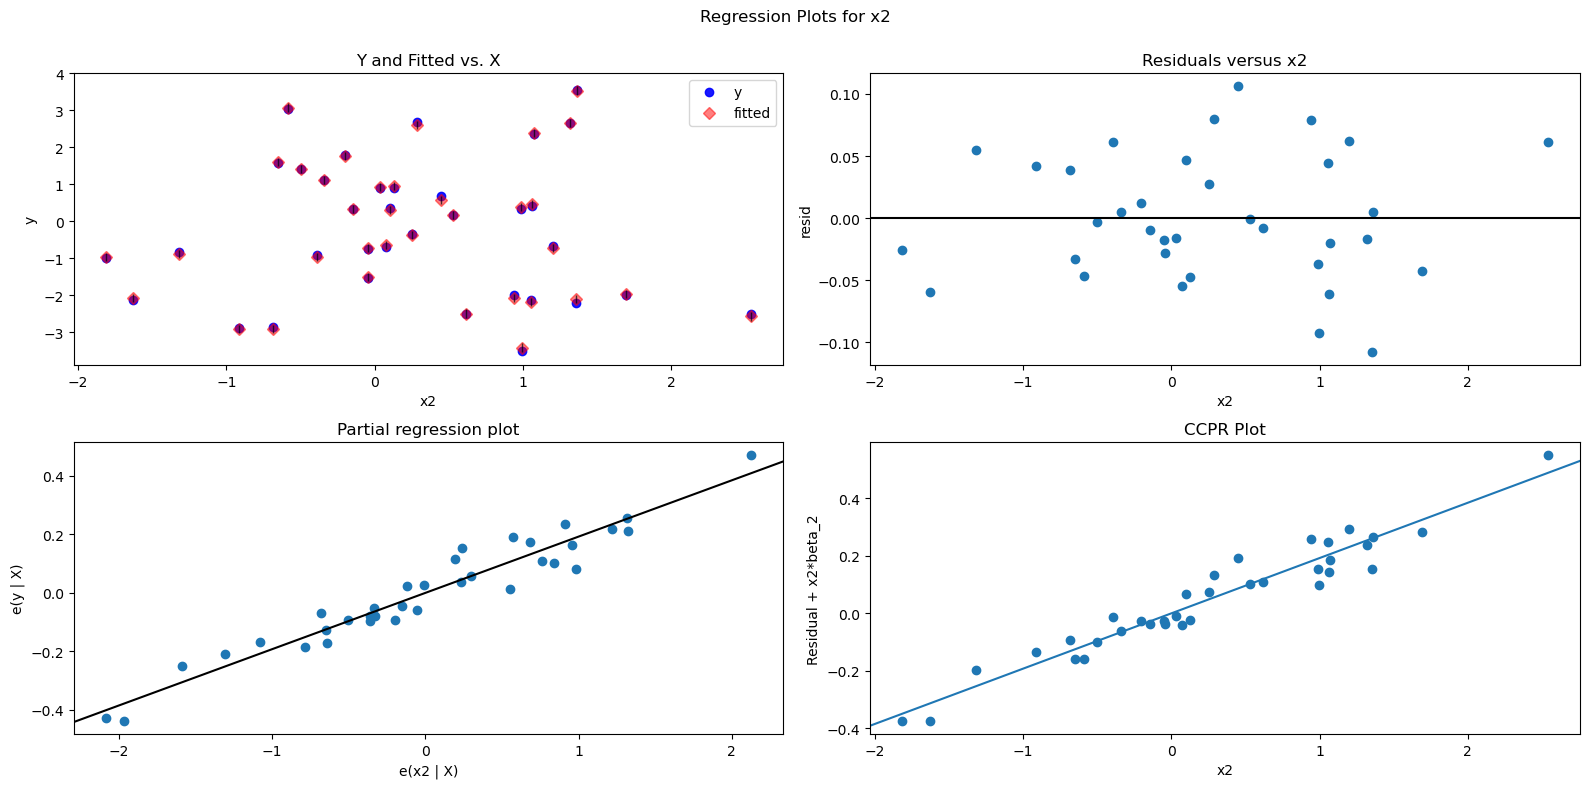

In [104]:
fig = plt.figure(figsize=(16, 8))

sm.graphics.plot_regress_exog(fit_x1x2_add, 'x2', fig=fig)

plt.show()

In [105]:
fit_x1x2_add.params

Intercept   -0.255679
x1           1.934499
x2           0.192452
dtype: float64

Save our randomly generated data

In [107]:
df.to_csv('linear_additive_example.csv', index=False)